# GraphRAG Lab Day 19 — Tech Company Corpus

## §0 — Setup Check

Verify environment and imports before running the pipeline.

In [21]:
# Add project root to path so imports work from notebook
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import settings
from src.corpus_builder import (
    load_corpus, load_benchmark,
    corpus_stats, benchmark_stats,
    Paragraph, BenchQuestion,
)
print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ LLM model:    {settings.llm_model}")
print(f"✓ Neo4j URI:    {settings.neo4j_uri}")

✓ Project root: /Users/duongtphuongthao/Documents/VinUni_Labs/Lab19/graphrag-lab
✓ LLM model:    gpt-4o-mini
✓ Neo4j URI:    bolt://localhost:7687


## §1 — Theory (Research questions from Lab brief §2.1)

### Q1. How does the LLM distinguish between an Entity (Node) and an Attribute?

An **entity** is something that can act as the subject of multiple relations and that other relations can point to. It has identity beyond a single statement (OpenAI, Sam Altman, Microsoft Azure). An **attribute** is a property *of* an entity that does not itself participate in further relations: a year (2015), a dollar amount (\$13B), a single string label. In our extractor we capture both as triples but tag the object with `object_type ∈ {entity, literal}`. Only `entity` objects become nodes that can be traversed; `literal` objects become node properties or terminal leaves.

### Q2. Why is deduplication critical in graph construction?

Without dedup, "OpenAI", "Open AI" and "OpenAI Inc." become three disconnected nodes. A 2-hop query starting at one of them cannot reach facts attached to the other two — the graph is *fragmented*, not unified. Dedup (via name normalization + alias merging via `MERGE` in Cypher) is what turns a pile of triples into a true knowledge graph. Without it, GraphRAG degenerates to lookup-by-string and loses its multi-hop advantage.

### Q3. What is the difference between graph BFS traversal and vector similarity search?

Vector search ranks chunks by **semantic surface similarity** to the query — fast, fuzzy, but blind to structure. It can find a chunk that *mentions* the answer entity but cannot follow a *chain of relations* to derive an answer that no single chunk states. BFS traversal walks **declared semantic edges** (FOUNDED_BY, ACQUIRED, CEO_OF, ...) outward from a seed entity, gathering exactly the structured facts at distance ≤ k. BFS is precise for multi-hop reasoning but brittle for fuzzy paraphrase. The two are complementary; this lab compares them head-to-head.

## §2 — Corpus & Benchmark Preview

Load the input data and verify it matches expected schema.

In [22]:
paragraphs = load_corpus()
c_stats = corpus_stats(paragraphs)
print("Corpus stats:")
for k, v in c_stats.items():
    print(f"  {k}: {v}")
print()
print("First 3 paragraphs (truncated):")
for p in paragraphs[:3]:
    print(f"  [{p.idx:02d}] {p.text[:120]}{'...' if len(p.text) > 120 else ''}")

Corpus stats:
  n_paragraphs: 60
  total_words: 2558
  avg_words_per_paragraph: 42.6
  total_chars: 17022
  min_words: 35
  max_words: 58

First 3 paragraphs (truncated):
  [01] OpenAI was founded in December 2015 in San Francisco, California. The founding team included Sam Altman, Elon Musk, Greg...
  [02] In 2019, OpenAI created a capped-profit subsidiary called OpenAI LP to attract larger investments. Microsoft became Open...
  [03] Sam Altman is the chief executive officer of OpenAI. Before leading OpenAI, Altman served as president of the startup ac...


In [23]:
questions = load_benchmark()
b_stats = benchmark_stats(questions)
print("Benchmark stats:")
for k, v in b_stats.items():
    print(f"  {k}: {v}")
print()
print("Sample question per category:")
seen_cats = set()
for q in questions:
    if q.category not in seen_cats:
        seen_cats.add(q.category)
        print(f"  [{q.qid} | {q.category:14s}] {q.question}")
        print(f"     gold: {q.gold_answer[:80]}{'...' if len(q.gold_answer) > 80 else ''}")

Benchmark stats:
  n_questions: 20
  by_category: {'single_hop': 5, 'out_of_domain': 5, 'ambiguous': 5, 'multi_hop': 5}
  n_with_reasoning_path: 5
  avg_expected_hops: 1.05

Sample question per category:
  [Q01 | single_hop    ] Who is the CEO of Microsoft?
     gold: Satya Nadella
  [Q06 | multi_hop     ] Who is the CEO of OpenAI's largest corporate investor?
     gold: Satya Nadella (CEO of Microsoft, which is OpenAI's largest corporate investor)
  [Q11 | ambiguous     ] Who founded Apple?
     gold: Steve Jobs, Steve Wozniak, and Ronald Wayne
  [Q16 | out_of_domain ] What is OpenAI's office street address?
     gold: Not enough information in the corpus


---
✅ **Milestone TIP-002:** Corpus & benchmark loaded and validated. Ready for triple extraction (TIP-003).
---

## §3 — Triple Extraction (Indexing Step)

We use `gpt-4o-mini` in JSON mode with a few-shot prompt to extract
(subject, relation, object) triples from each paragraph. The cost tracker
logs every API call so we can compute total token usage for Deliverable #4.

> ⚠️ This cell makes 60 API calls. Estimated cost: $0.01–0.03.

In [24]:
from src.extractor import extract_corpus
from src.cost_tracker import reset_cost_log, cost_summary

# Reset cost log so this section's stats are isolated to extraction
reset_cost_log()

print(f"Extracting triples from {len(paragraphs)} paragraphs...")
triples = extract_corpus(paragraphs, verbose=True)
print(f"\n✓ Extracted {len(triples)} triples total.")

Extracting triples from 60 paragraphs...
  [ 10/60] extracted 67 triples so far...
  [ 20/60] extracted 129 triples so far...
  [ 30/60] extracted 194 triples so far...
  [ 40/60] extracted 262 triples so far...
  [ 50/60] extracted 324 triples so far...
  [ 60/60] extracted 419 triples so far...

✓ Extracted 419 triples total.


In [25]:
# Preview first 15 triples
print(f"{'idx':>3}  {'subject':<25} {'relation':<22} {'object':<30} {'type':<8}")
print("-" * 95)
for t in triples[:15]:
    print(f"[{t.source_idx:02d}]  {t.subject[:24]:<25} {t.relation[:21]:<22} {t.object[:29]:<30} {t.object_type:<8}")

idx  subject                   relation               object                         type    
-----------------------------------------------------------------------------------------------
[01]  OpenAI                    FOUNDED_IN             December 2015                  literal 
[01]  OpenAI                    FOUNDED_AT             San Francisco                  entity  
[01]  OpenAI                    FOUNDED_AT             California                     entity  
[01]  OpenAI                    FOUNDED_BY             Sam Altman                     entity  
[01]  OpenAI                    FOUNDED_BY             Elon Musk                      entity  
[01]  OpenAI                    FOUNDED_BY             Greg Brockman                  entity  
[01]  OpenAI                    FOUNDED_BY             Ilya Sutskever                 entity  
[01]  OpenAI                    FOUNDED_BY             Wojciech Zaremba               entity  
[01]  OpenAI                    FOUNDED_BY        

In [26]:
# Distribution: how many triples per paragraph, top relations
from collections import Counter

per_paragraph = Counter(t.source_idx for t in triples)
relations = Counter(t.relation for t in triples)
object_types = Counter(t.object_type for t in triples)

print(f"Triples per paragraph — min: {min(per_paragraph.values())}, "
      f"max: {max(per_paragraph.values())}, "
      f"mean: {sum(per_paragraph.values()) / len(per_paragraph):.1f}")
print(f"Object types: {dict(object_types)}")
print(f"\nTop 10 relations:")
for rel, count in relations.most_common(10):
    print(f"  {rel:<25} {count}")

Triples per paragraph — min: 3, max: 36, mean: 7.0
Object types: {'literal': 104, 'entity': 315}

Top 10 relations:
  DEVELOPS                  41
  FOUNDED_BY                39
  FOUNDED_IN                33
  COMPETITOR_OF             26
  CEO_OF                    19
  FOUNDED_AT                18
  FORMER_EMPLOYER           18
  DEPENDS_ON                16
  RELEASED_IN               15
  WORKS_AT                  15


In [27]:
# Cost summary for the extraction phase
summary = cost_summary()
print("Extraction cost summary:")
print(f"  Total API calls:      {summary['total_calls']}")
print(f"  Total tokens in:      {summary['total_tokens_in']:,}")
print(f"  Total tokens out:     {summary['total_tokens_out']:,}")
print(f"  Total cost (USD):     ${summary['total_cost_usd']:.4f}")
print(f"  Total latency (ms):   {summary['total_latency_ms']:,}")
if summary['total_calls']:
    print(f"  Avg latency / call:   {summary['total_latency_ms'] / summary['total_calls']:.0f} ms")

Extraction cost summary:
  Total API calls:      60
  Total tokens in:      53,841
  Total tokens out:     12,139
  Total cost (USD):     $0.0154
  Total latency (ms):   369,955
  Avg latency / call:   6166 ms


---
✅ **Milestone TIP-003:** All triples extracted with full cost tracking. Ready for graph construction (TIP-004).
---

## §4 — Graph Construction (Neo4j)

Push the 408 extracted triples into Neo4j with `MERGE`-based deduplication.
Then render two visualizations: a Matplotlib backup (saved to `screenshots/`)
and a set of Cypher queries the user can paste into Neo4j Browser.

In [28]:
from src.graph_builder import (
    test_connection, ensure_constraints, clear_graph, build_graph,
    get_stats, export_matplotlib, suggested_browser_queries, close_driver,
)

# 1) verify Neo4j is reachable
assert test_connection(), (
    "Neo4j is not reachable. Run `docker compose up -d` and check that "
    "container `graphrag-neo4j` is healthy."
)
print("✓ Neo4j is reachable.")

# 2) prepare a clean schema
ensure_constraints()
clear_graph()
print("✓ Graph cleared, constraint ensured.")

✓ Neo4j is reachable.
✓ Graph cleared, constraint ensured.


In [29]:
# Build the full graph from §3's triples
stats = build_graph(triples)
print(f"✓ Graph built — {stats.n_nodes} nodes, {stats.n_edges} edges, "
      f"{stats.n_unique_relations} relation types")
print(f"\nEntity type distribution:")
for k, v in sorted(stats.n_entity_types.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<10} {v}")
print(f"\nTop 10 entities by degree:")
for name, deg in stats.top_entities_by_degree:
    print(f"  {deg:>3}  {name}")

✓ Graph built — 275 nodes, 413 edges, 81 relation types

Entity type distribution:
  Other      82
  Person     79
  Company    69
  Year       29
  Product    12
  Money      3
  Location   1

Top 10 entities by degree:
   49  OpenAI
   32  Anthropic
   30  Microsoft
   28  Meta
   26  Google
   16  NVIDIA
   16  Apple
   15  Elon Musk
   15  Amazon Web Services
   14  Google DeepMind


✓ Matplotlib visualization saved to: /Users/duongtphuongthao/Documents/VinUni_Labs/Lab19/graphrag-lab/screenshots/graph_matplotlib.png


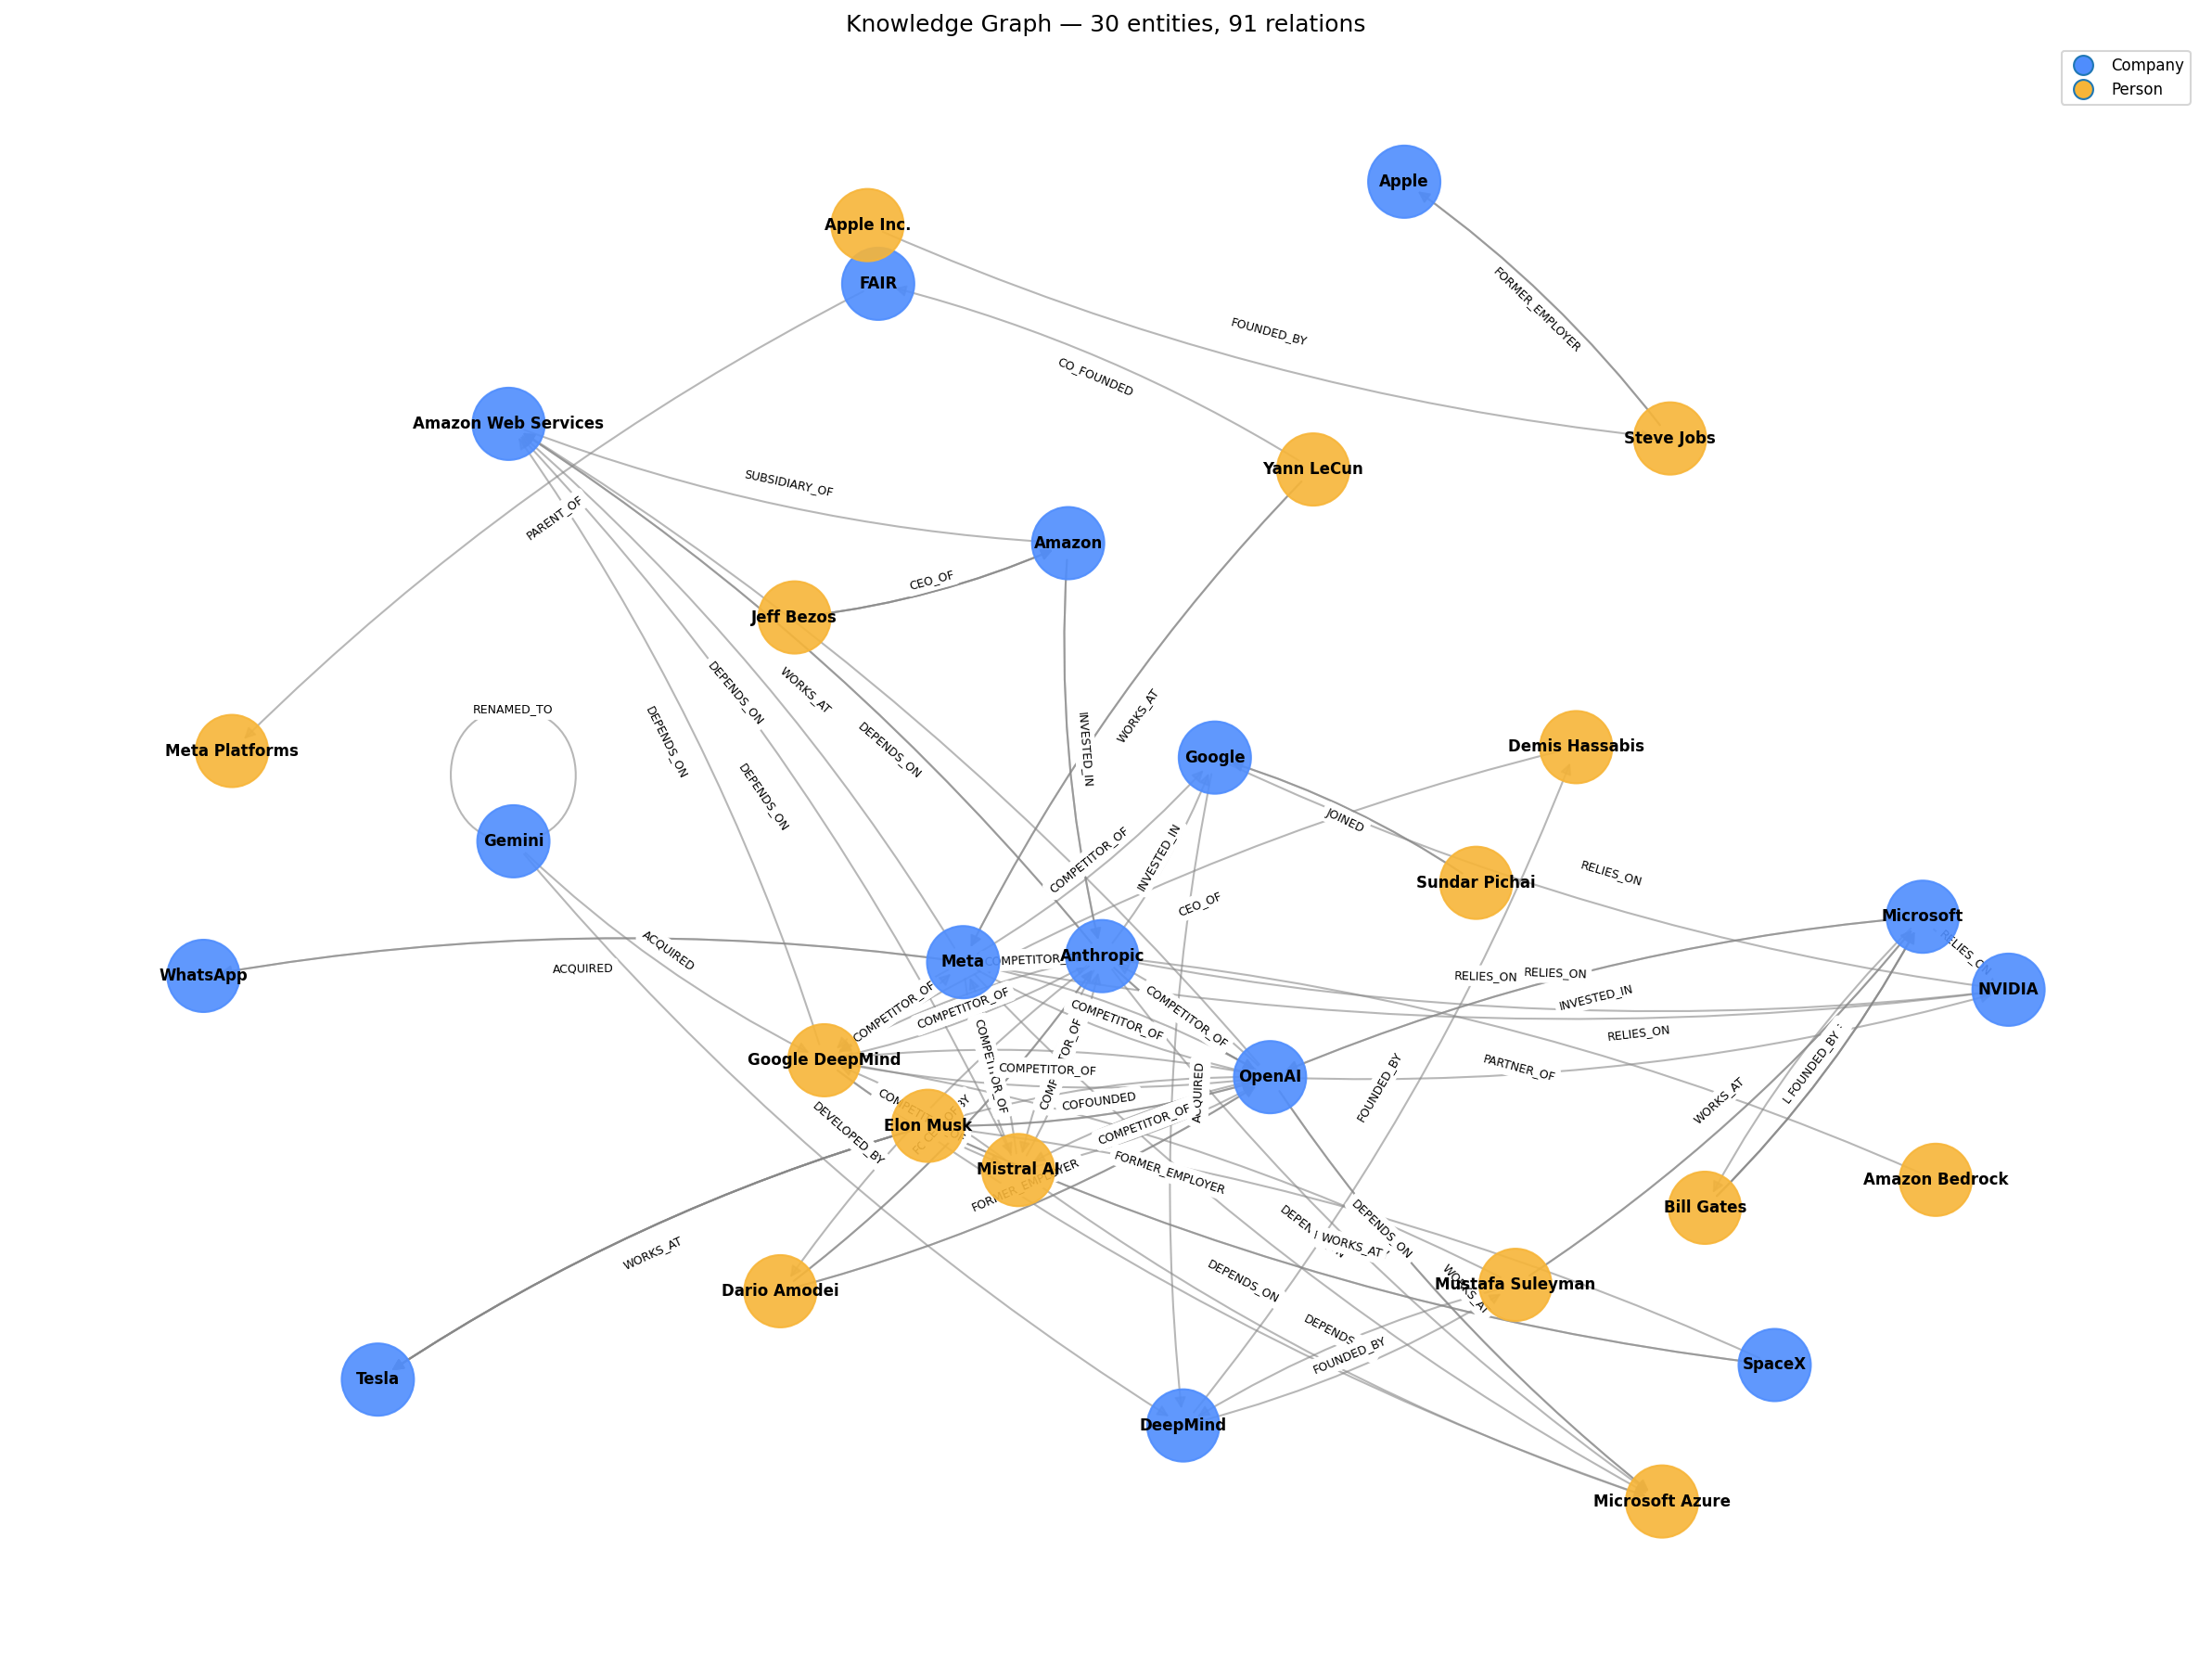

In [30]:
# Render Matplotlib backup visualization
from pathlib import Path
viz_path = PROJECT_ROOT / "screenshots" / "graph_matplotlib.png"
viz_path = export_matplotlib(viz_path, limit_nodes=30)
print(f"✓ Matplotlib visualization saved to: {viz_path}")

from IPython.display import Image, display
display(Image(filename=str(viz_path)))

### Neo4j Browser Screenshot Instructions (Deliverable #2)

1. Open **http://localhost:7474** in a browser.
2. Log in: `neo4j` / `graphrag-lab-pwd` (matches `docker-compose.yml`).
3. Paste any of the queries below into the query editor and click **Run**.
4. Adjust node spacing in the visualization until labels are readable.
5. Take a screenshot and save it as `screenshots/graph_neo4j.png`.

Recommended query for the screenshot: **"OpenAI 2-hop neighborhood"**
(it captures multi-hop structure clearly without overcrowding).

In [31]:
# Print Cypher queries to paste into Neo4j Browser
for label, query in suggested_browser_queries():
    print(f"--- {label} ---")
    print(query)
    print()

--- Full graph (use only if the graph is small enough) ---
MATCH (n)-[r]->(m) RETURN n, r, m

--- OpenAI ego network (1 hop) ---
MATCH (n {name: 'OpenAI'})-[r]-(m) RETURN n, r, m

--- OpenAI 2-hop neighborhood ---
MATCH p = (n {name: 'OpenAI'})-[*1..2]-(m) RETURN p LIMIT 100

--- Top 30 most connected entities ---
MATCH (n)-[r]-() WITH n, count(r) AS deg ORDER BY deg DESC LIMIT 30 MATCH (n)-[r2]-(m) RETURN n, r2, m

--- All companies and their CEOs ---
MATCH (p)-[r:CEO_OF]->(c) RETURN p, r, c



---
✅ **Milestone TIP-004:** Knowledge graph built with deduplication. Ready for query layer (TIP-005 GraphRAG, TIP-006 Flat RAG baseline).
---

## §5 — GraphRAG Query Pipeline (Demo)

The full GraphRAG pipeline runs in 5 stages:

1. **NER** — LLM extracts named entities from the question
2. **Match** — exact + alias lookup against graph nodes
3. **BFS** — collect all edges within 2 hops of matched nodes
4. **Textualize** — format as structured `S REL O` triples
5. **Answer** — LLM reads facts, answers with strict no-fabrication prompt

We demo on three contrasting questions: single-hop, multi-hop, and out-of-domain.

In [32]:
from src.graph_rag import query as graph_rag_query

def show_result(label, q):
    print("=" * 80)
    print(f"[{label}] {q}")
    print("=" * 80)
    r = graph_rag_query(q)
    print(f"\n→ Extracted entities:  {r.extracted_entities}")
    print(f"→ Matched in graph:    {r.matched_entity_names}")
    print(f"→ Subgraph edges:      {len(r.edges)}")
    print(f"\n--- Context (first 12 lines) ---")
    for line in r.context.split('\n')[:12]:
        print(line)
    if len(r.context.split(chr(10))) > 12:
        print(f"... ({len(r.context.split(chr(10))) - 12} more lines)")
    print(f"\n--- Answer ---")
    print(r.answer)
    print(f"\n[latency: {r.latency_ms} ms]\n")
    return r

In [33]:
# Demo 1: single-hop (Q01) — should be easy
r1 = show_result("SINGLE-HOP — Q01", "Who is the CEO of Microsoft?")

[SINGLE-HOP — Q01] Who is the CEO of Microsoft?

→ Extracted entities:  ['Microsoft']
→ Matched in graph:    ['Microsoft']
→ Subgraph edges:      111

--- Context (first 12 lines) ---
Facts:
- Microsoft FOUNDED_BY Bill Gates
- Bill Gates PARTNER_OF Bill & Melinda Gates Foundation
- Bill Gates LEFT_BOARD_OF Microsoft
- Bill Gates FOUNDED_AT 2020
- Bill Gates CEO_OF Microsoft
- Bill Gates FORMER_EMPLOYER Microsoft
- Bill Gates FOUNDED_AT 1975
- Microsoft INVESTED_IN OpenAI
- OpenAI FOUNDED_IN December 2015
- OpenAI FOUNDED_AT San Francisco
- OpenAI FOUNDED_BY Elon Musk
... (70 more lines)

--- Answer ---
Satya Nadella is the CEO of Microsoft.

[latency: 1663 ms]



In [34]:
# Demo 2: multi-hop (Q06) — the centerpiece
# Requires traversal: OpenAI -> Microsoft (largest investor) -> Satya Nadella (CEO)
r2 = show_result("MULTI-HOP — Q06", "Who is the CEO of OpenAI's largest corporate investor?")

[MULTI-HOP — Q06] Who is the CEO of OpenAI's largest corporate investor?

→ Extracted entities:  ['OpenAI']
→ Matched in graph:    ['OpenAI']
→ Subgraph edges:      197

--- Context (first 12 lines) ---
Facts:
- OpenAI FOUNDED_IN December 2015
- OpenAI FOUNDED_AT San Francisco
- Anthropic FOUNDED_AT San Francisco
- OpenAI FOUNDED_BY Elon Musk
- Elon Musk FOUNDED xAI
- Elon Musk COFOUNDED OpenAI
- Elon Musk RESIGNED_FROM board of directors
- Elon Musk CRITIC_OF OpenAI
- Elon Musk WORKS_AT SpaceX
- Elon Musk CEO_OF SpaceX
- SpaceX FOUNDED_BY Elon Musk
... (70 more lines)

--- Answer ---
Satya Nadella is the CEO of Microsoft, OpenAI's largest corporate investor.

[latency: 1692 ms]



In [35]:
# Demo 3: out-of-domain (Q16) — must abstain (the strict prompt's job)
r3 = show_result("OUT-OF-DOMAIN — Q16", "What is OpenAI's office street address?")

[OUT-OF-DOMAIN — Q16] What is OpenAI's office street address?

→ Extracted entities:  ['OpenAI']
→ Matched in graph:    ['OpenAI']
→ Subgraph edges:      197

--- Context (first 12 lines) ---
Facts:
- OpenAI FOUNDED_IN December 2015
- OpenAI FOUNDED_AT San Francisco
- Anthropic FOUNDED_AT San Francisco
- OpenAI FOUNDED_BY Elon Musk
- Elon Musk FOUNDED xAI
- Elon Musk COFOUNDED OpenAI
- Elon Musk RESIGNED_FROM board of directors
- Elon Musk CRITIC_OF OpenAI
- Elon Musk WORKS_AT SpaceX
- Elon Musk CEO_OF SpaceX
- SpaceX FOUNDED_BY Elon Musk
... (70 more lines)

--- Answer ---
I don't have enough information to answer this question.

[latency: 5330 ms]



In [36]:
# Cost summary so far (extraction + 6 graph_rag calls = 3 NER + 3 answer)
from src.cost_tracker import cost_summary
s = cost_summary()
print(f"Total API calls so far:  {s['total_calls']}")
print(f"Total cost so far:       ${s['total_cost_usd']:.4f}")
print(f"\nBy module:")
for mod, stats in s['by_module'].items():
    print(f"  {mod:<20} calls={stats['calls']:>3}  "
          f"tokens_in={stats['tokens_in']:>6}  "
          f"tokens_out={stats['tokens_out']:>5}  "
          f"cost=${stats['cost_usd']:.4f}")

Total API calls so far:  66
Total cost so far:       $0.0159

By module:
  extractor            calls= 60  tokens_in= 53841  tokens_out=12139  cost=$0.0154
  graph_rag_ner        calls=  3  tokens_in=   634  tokens_out=   23  cost=$0.0001
  graph_rag_answer     calls=  3  tokens_in=  2813  tokens_out=   37  cost=$0.0004


---
✅ **Milestone TIP-005:** GraphRAG pipeline functional. The multi-hop demo (Q06) should answer **Satya Nadella** by combining `OpenAI -[INVESTED_BY]- Microsoft -[CEO_OF]- Satya Nadella`. The out-of-domain demo (Q16) should abstain — that abstention is the property we'll measure against Flat RAG in TIP-007.

Ready for TIP-006 (Flat RAG baseline).

---

## §6 — Flat RAG Baseline (ChromaDB)

The Flat RAG baseline uses the **same answer model + same strict prompt**
as GraphRAG — the only difference is the retrieval strategy:

| Aspect           | GraphRAG                       | Flat RAG                       |
|------------------|--------------------------------|--------------------------------|
| Retrieval        | NER → 2-hop BFS over Neo4j     | Vector cosine over ChromaDB    |
| Context shape    | Structured `S REL O` triples   | Original paragraph text (top-5)|
| Answer model     | gpt-4o-mini                    | gpt-4o-mini                    |
| Answer temperature | 0.0                          | 0.0                            |
| System prompt    | `ANSWER_SYSTEM_PROMPT`         | **same** `ANSWER_SYSTEM_PROMPT`|

This isolates the retrieval strategy as the sole independent variable.

In [37]:
from src.flat_rag import (
    index_corpus, log_indexing_cost,
    query as flat_rag_query, reset_collection,
)

# Reset to ensure a clean state, then index
reset_collection()
n = index_corpus(paragraphs)
log_indexing_cost(paragraphs)
print(f"✓ Flat RAG indexed {n} paragraphs.")

  Indexed 60 paragraphs into Chroma collection 'tech_corpus_flat_rag'
✓ Flat RAG indexed 60 paragraphs.


In [38]:
def show_flat(label, q):
    print("=" * 80)
    print(f"[{label}] {q}")
    print("=" * 80)
    r = flat_rag_query(q)
    print(f"\n→ Top retrieved paragraphs (idx, distance):")
    for idx, _text, dist in r.retrieved_paragraphs:
        print(f"   [{idx:02d}]  distance={dist:.4f}")
    print(f"\n--- Context (first 8 lines) ---")
    for line in r.context.split('\n')[:8]:
        print(line[:140] + ('...' if len(line) > 140 else ''))
    print(f"\n--- Answer ---")
    print(r.answer)
    print(f"\n[latency: {r.latency_ms} ms]\n")
    return r

# Demo on the same 3 questions as §5 (single-hop, multi-hop, out-of-domain)
fr1 = show_flat("SINGLE-HOP — Q01", "Who is the CEO of Microsoft?")
fr2 = show_flat("MULTI-HOP — Q06", "Who is the CEO of OpenAI's largest corporate investor?")
fr3 = show_flat("OUT-OF-DOMAIN — Q16", "What is OpenAI's office street address?")

[SINGLE-HOP — Q01] Who is the CEO of Microsoft?

→ Top retrieved paragraphs (idx, distance):
   [10]  distance=0.3216
   [09]  distance=0.3302
   [08]  distance=0.4595
   [24]  distance=0.4905
   [26]  distance=0.5480

--- Context (first 8 lines) ---
Passages:
[Paragraph 10] Satya Nadella has been the chief executive officer of Microsoft since February 2014. Under Nadella's leadership, Microsoft pi...
[Paragraph 09] Bill Gates served as chief executive officer of Microsoft from 1975 to 2000 before transitioning into a chairman role. Steve ...
[Paragraph 08] Microsoft was founded in 1975 by Bill Gates and Paul Allen in Albuquerque, New Mexico. The company later moved its headquarte...
[Paragraph 24] Mustafa Suleyman, a co-founder of DeepMind, left to start Inflection AI in 2022. He joined Microsoft in March 2024 as chief e...
[Paragraph 26] Mark Zuckerberg has served as chief executive officer of Meta since the company's founding. He retains majority voting contro...

--- Answer ---
Sat

### Side-by-side: GraphRAG vs Flat RAG (3 demo questions)

The benchmark in TIP-007 will run all 20 questions; this is a quick visual
check to see whether the differences match expectations.

In [39]:
# Re-run GraphRAG on the same 3 questions for direct comparison
from src.graph_rag import query as graph_rag_query

demo_questions = [
    ("Q01 (single-hop)", "Who is the CEO of Microsoft?"),
    ("Q06 (multi-hop)",  "Who is the CEO of OpenAI's largest corporate investor?"),
    ("Q16 (out-of-domain)", "What is OpenAI's office street address?"),
]

print(f"{'qid':<22} | {'GraphRAG':<55} | {'Flat RAG':<55}")
print("-" * 140)
for label, q in demo_questions:
    g = graph_rag_query(q)
    f = flat_rag_query(q)
    g_ans = (g.answer[:52] + '...') if len(g.answer) > 55 else g.answer
    f_ans = (f.answer[:52] + '...') if len(f.answer) > 55 else f.answer
    print(f"{label:<22} | {g_ans:<55} | {f_ans:<55}")

qid                    | GraphRAG                                                | Flat RAG                                               
--------------------------------------------------------------------------------------------------------------------------------------------
Q01 (single-hop)       | Satya Nadella is the CEO of Microsoft.                  | Satya Nadella is the CEO of Microsoft.                 
Q06 (multi-hop)        | Satya Nadella is the CEO of Microsoft, OpenAI's larg... | I don't have enough information to answer this quest...
Q16 (out-of-domain)    | I don't have enough information to answer this quest... | I don't have enough information to answer this quest...


In [40]:
# Cost summary so far (extraction + GraphRAG + Flat RAG indexing + Flat RAG queries)
from src.cost_tracker import cost_summary
s = cost_summary()
print(f"Cumulative API calls:  {s['total_calls']}")
print(f"Cumulative cost:       ${s['total_cost_usd']:.4f}")
print(f"\nBy module:")
for mod, stats in s['by_module'].items():
    print(f"  {mod:<22} calls={stats['calls']:>3}  "
          f"tokens_in={stats['tokens_in']:>6}  "
          f"tokens_out={stats['tokens_out']:>5}  "
          f"cost=${stats['cost_usd']:.4f}")

Cumulative API calls:  79
Cumulative cost:       $0.0170

By module:
  extractor              calls= 60  tokens_in= 53841  tokens_out=12139  cost=$0.0154
  graph_rag_ner          calls=  6  tokens_in=  1268  tokens_out=   46  cost=$0.0002
  graph_rag_answer       calls=  6  tokens_in=  5626  tokens_out=   74  cost=$0.0009
  flat_rag_index         calls=  1  tokens_in=  4236  tokens_out=    0  cost=$0.0001
  flat_rag_answer        calls=  6  tokens_in=  2722  tokens_out=   60  cost=$0.0004


---
✅ **Milestone TIP-006:** Flat RAG baseline operational with the same answer prompt as GraphRAG. Ready for the full 20-question benchmark (TIP-007).

---

## §7 — Full 20-Question Benchmark

We now run the full 20-question benchmark across both systems with auto-grading
by a third LLM (`gpt-4o-mini`) acting as judge. Each row of the resulting CSV
includes both system answers, correctness flags, hallucination flags, and
per-question cost / latency.

> ⚠️ This cell makes ~80 API calls (20 Q × 4 = NER + answer + judge × 2 systems, minus shared judge).
> Estimated runtime: 2–4 minutes. Estimated cost: $0.03–0.05.

In [41]:
from src.benchmark import run_benchmark, summarize, hallucination_examples
import pandas as pd

df = run_benchmark(questions=questions, verbose=True)
print(f"\n✓ Benchmark complete. Saved to: {PROJECT_ROOT / 'results' / 'benchmark_table.csv'}")

  [ 1/20] Q01 single_hop     GraphRAG:✓ FlatRAG:✓
  [ 2/20] Q02 single_hop     GraphRAG:✓ FlatRAG:✓
  [ 3/20] Q03 single_hop     GraphRAG:✓ FlatRAG:✓
  [ 4/20] Q04 single_hop     GraphRAG:✓ FlatRAG:✓
  [ 5/20] Q05 single_hop     GraphRAG:✓ FlatRAG:✓
  [ 6/20] Q06 multi_hop      GraphRAG:✓ FlatRAG:✓
  [ 7/20] Q07 multi_hop      GraphRAG:✓ FlatRAG:✓
  [ 8/20] Q08 multi_hop      GraphRAG:✓ FlatRAG:✓
  [ 9/20] Q09 multi_hop      GraphRAG:✓ FlatRAG:✓
  [10/20] Q10 multi_hop      GraphRAG:✓ FlatRAG:✓
  [11/20] Q11 ambiguous      GraphRAG:✓ FlatRAG:✓
  [12/20] Q12 ambiguous      GraphRAG:✓ FlatRAG:✓
  [13/20] Q13 ambiguous      GraphRAG:✓ FlatRAG:✓
  [14/20] Q14 ambiguous      GraphRAG:✓ FlatRAG:✓
  [15/20] Q15 ambiguous      GraphRAG:✓ FlatRAG:✓
  [16/20] Q16 out_of_domain  GraphRAG:✓ FlatRAG:✓
  [17/20] Q17 out_of_domain  GraphRAG:✓ FlatRAG:✓
  [18/20] Q18 out_of_domain  GraphRAG:✓ FlatRAG:✓
  [19/20] Q19 out_of_domain  GraphRAG:✓ FlatRAG:✓
  [20/20] Q20 out_of_domain  GraphRAG:✓ FlatRAG:✓


In [42]:
# Aggregate summary
s = summarize(df)
print(f"GraphRAG accuracy:           {s['graph_accuracy']*100:5.1f}% "
      f"({int(df['graph_correct'].sum())}/{s['n_questions']})")
print(f"Flat RAG accuracy:           {s['flat_accuracy']*100:5.1f}% "
      f"({int(df['flat_correct'].sum())}/{s['n_questions']})")
print(f"GraphRAG hallucination rate: {s['graph_hallucination_rate']*100:5.1f}%")
print(f"Flat RAG hallucination rate: {s['flat_hallucination_rate']*100:5.1f}%")
print()
print("By category (correct / hallucinated, out of 5):")
for cat, vals in s["by_category"].items():
    print(f"  {cat:<14}  Graph: {int(vals['graph_correct'])}/{int(vals['n'])} correct, "
          f"{int(vals['graph_hallucinated'])} halluc | "
          f"Flat: {int(vals['flat_correct'])}/{int(vals['n'])} correct, "
          f"{int(vals['flat_hallucinated'])} halluc")

GraphRAG accuracy:           100.0% (20/20)
Flat RAG accuracy:           100.0% (20/20)
GraphRAG hallucination rate:   0.0%
Flat RAG hallucination rate:   0.0%

By category (correct / hallucinated, out of 5):
  ambiguous       Graph: 5/5 correct, 0 halluc | Flat: 5/5 correct, 0 halluc
  multi_hop       Graph: 5/5 correct, 0 halluc | Flat: 5/5 correct, 0 halluc
  out_of_domain   Graph: 5/5 correct, 0 halluc | Flat: 5/5 correct, 0 halluc
  single_hop      Graph: 5/5 correct, 0 halluc | Flat: 5/5 correct, 0 halluc


In [43]:
# Quick view of the table — qid, category, both answers truncated, both correct flags
view_cols = ["qid", "category", "graph_answer", "graph_correct",
             "flat_answer", "flat_correct"]
view = df[view_cols].copy()
view["graph_answer"] = view["graph_answer"].str.slice(0, 60)
view["flat_answer"]  = view["flat_answer"].str.slice(0, 60)
view

,qid,category,graph_answer,graph_correct,flat_answer,flat_correct
0,Q01,single_hop,Satya Nadella is the CEO of Microsoft.,True,Satya Nadella is the CEO of Microsoft.,True
1,Q02,single_hop,OpenAI was founded in December 2015.,True,OpenAI was founded in December 2015.,True
2,Q03,single_hop,I don't have enough information to answer this...,True,Google acquired the British artificial intelli...,True
3,Q04,single_hop,I don't have enough information to answer this...,True,"NVIDIA was founded by Jensen Huang, Chris Mala...",True
4,Q05,single_hop,"OpenAI released ChatGPT on November 30, 2022.",True,OpenAI released the conversational assistant C...,True
5,Q06,multi_hop,"Satya Nadella is the CEO of Microsoft, OpenAI'...",True,I don't have enough information to answer this...,True
6,Q07,multi_hop,Dario Amodei worked at OpenAI before founding ...,True,Dario Amodei worked at OpenAI before founding ...,True
7,Q08,multi_hop,I don't have enough information to answer this...,True,"Yann LeCun is the chief AI scientist at Meta, ...",True
8,Q09,multi_hop,The parent company of the AI lab that Google a...,True,The parent company of the AI lab that Google a...,True
9,Q10,multi_hop,Elon Musk.,True,Elon Musk.,True


In [44]:
# Bar chart: accuracy per category
import matplotlib.pyplot as plt
import numpy as np

cats = list(s["by_category"].keys())
g_acc = [s["by_category"][c]["graph_correct"] / s["by_category"][c]["n"] * 100 for c in cats]
f_acc = [s["by_category"][c]["flat_correct"] / s["by_category"][c]["n"] * 100 for c in cats]

x = np.arange(len(cats))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, g_acc, w, label="GraphRAG", color="#4F8DFD")
b2 = ax.bar(x + w/2, f_acc, w, label="Flat RAG", color="#F7B538")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
                f"{b.get_height():.0f}%", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=15)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
ax.set_title("Accuracy by question category — GraphRAG vs Flat RAG")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
chart_path = PROJECT_ROOT / "screenshots" / "accuracy_by_category.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Chart saved to: {chart_path}")

✓ Chart saved to: /Users/duongtphuongthao/Documents/VinUni_Labs/Lab19/graphrag-lab/screenshots/accuracy_by_category.png


/var/folders/vv/5mxlt49s32d4ym1h4jktbn_c0000gn/T/ipykernel_82840/3682408529.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [45]:
# Headline examples: cases where Flat RAG hallucinated but GraphRAG did not
examples = hallucination_examples(df, max_each=5)
if examples:
    print(f"Found {len(examples)} cases where Flat RAG hallucinated and GraphRAG did not:\n")
    for ex in examples:
        print(f"[{ex['qid']} | {ex['category']}] {ex['question']}")
        print(f"  Gold:      {ex['gold_answer']}")
        print(f"  Flat RAG:  {ex['flat_answer']}")
        print(f"  GraphRAG:  {ex['graph_answer']}")
        print()
else:
    print("No cases found where Flat RAG hallucinated but GraphRAG did not.")
    print("(This may happen if Flat RAG also abstained reliably — still a valid result.)")

No cases found where Flat RAG hallucinated but GraphRAG did not.
(This may happen if Flat RAG also abstained reliably — still a valid result.)


## §8 — Cost Analysis (Deliverable #4)

We use the cost log accumulated across every API call to produce a
detailed Markdown breakdown of token usage, cost, and latency by phase.

In [46]:
from src.benchmark import write_cost_analysis
md_path = write_cost_analysis(df)
print(f"✓ Cost analysis written to: {md_path}\n")
print(md_path.read_text())

✓ Cost analysis written to: /Users/duongtphuongthao/Documents/VinUni_Labs/Lab19/graphrag-lab/results/cost_analysis.md

# Cost Analysis — GraphRAG Lab Day 19

This file is auto-generated by `src/benchmark.py:write_cost_analysis()`.

## 1. One-time indexing costs

| Stage | Calls | Tokens in | Tokens out | Cost (USD) | Latency (s) |
|---|---:|---:|---:|---:|---:|
| GraphRAG triple extraction | 60 | 53,841 | 12,139 | $0.0154 | 370.0 |
| Flat RAG embedding indexing | 1 | 4,236 | 0 | $0.0001 | 0.0 |

## 2. Per-question runtime cost (20 questions)

| System | Total cost | Avg cost / Q | Avg latency / Q | Tokens in (sum) | Tokens out (sum) |
|---|---:|---:|---:|---:|---:|
| GraphRAG | $0.0032 | $0.00016 | 2.32 s | 19,729 | 391 |
| Flat RAG | $0.0015 | $0.00008 | 1.26 s | 9,151 | 291 |

## 3. Auto-grading overhead (judge model)

- Judge calls: 40
- Judge cost: $0.0028
- Judge latency: 75.0s

## 4. Grand total

- **All API calls:** 179
- **Total tokens in:** 110,941
- **Total tokens out:** 14,1

---
✅ **Milestone TIP-007:** Benchmark CSV (Deliverable #3) and Cost Analysis MD (Deliverable #4) generated. Ready for final notebook polish (TIP-008).

---

## §9 — V2 Corpus: Wikipedia Expansion

The instructor suggested scaling from the 60-paragraph synthetic corpus
to a larger Wikipedia-derived corpus to reduce the co-location bias that
can make Flat RAG appear competitive on small synthetic data.

This section scrapes ~100 articles across 10 anchor companies (OpenAI,
Anthropic, Google, Microsoft, Meta, NVIDIA, Apple, Amazon, Tesla, IBM)
plus their key people, products, and related entities — designed to
contain *cross-document* multi-hop facts that cannot be answered from
any single paragraph.

> ⚠️ This cell makes ~100 Wikipedia HTTP requests. Estimated runtime: 60–90 seconds.
> Wikipedia is free; no LLM calls in this section.

In [47]:
from src.wiki_scraper import scrape_and_write
import json

stats = scrape_and_write(verbose=True)
print("\n--- Scrape summary ---")
print(json.dumps(stats, indent=2))

  [ 10/100] 21 paragraphs collected so far


  [ 20/100] SKIP 'Center for AI Safety': max retries exceeded: JSONDecodeError: Expecting value: line 1 column 1 (char 0)


  [ 30/100] 80 paragraphs collected so far
  [ 40/100] 104 paragraphs collected so far
  [ 50/100] 135 paragraphs collected so far
  [ 60/100] 167 paragraphs collected so far
  [ 70/100] 206 paragraphs collected so far


  [ 77/100] SKIP 'Blue Origin': max retries exceeded: JSONDecodeError: Expecting value: line 1 column 1 (char 0)
  [ 78/100] SKIP 'Whole Foods Market': max retries exceeded: JSONDecodeError: Expecting value: line 1 column 1 (char 0)
  [ 79/100] SKIP 'Twitch (service)': max retries exceeded: JSONDecodeError: Expecting value: line 1 column 1 (char 0)
  [ 80/100] SKIP 'Ring (company)': max retries exceeded: JSONDecodeError: Expecting value: line 1 column 1 (char 0)
  [ 81/100] SKIP 'Tesla, Inc.': max retries exceeded: JSONDecodeError: Expecting value: line 1 column 1 (char 0)
  [ 82/100] SKIP 'Elon Musk': max retries exceeded: JSONDecodeError: Expecting value: line 1 column 1 (char 0)


  [ 90/100] 249 paragraphs collected so far
  [100/100] 276 paragraphs collected so far

--- Scrape summary ---
{
  "n_paragraphs": 276,
  "n_articles_succeeded": 93,
  "n_articles_skipped": 7,
  "corpus_path": "/Users/duongtphuongthao/Documents/VinUni_Labs/Lab19/graphrag-lab/data/wiki_corpus.txt",
  "metadata_path": "/Users/duongtphuongthao/Documents/VinUni_Labs/Lab19/graphrag-lab/data/wiki_metadata.json",
  "skipped_titles": [
    "Center for AI Safety",
    "Blue Origin",
    "Whole Foods Market",
    "Twitch (service)",
    "Ring (company)",
    "Tesla, Inc.",
    "Elon Musk"
  ]
}


In [48]:
# Quick sanity peek at the new corpus
v2_corpus_path = PROJECT_ROOT / "data" / "wiki_corpus.txt"
v2_metadata_path = PROJECT_ROOT / "data" / "wiki_metadata.json"
print(f"Corpus file size: {v2_corpus_path.stat().st_size / 1024:.1f} KB")

# Preview first 3 paragraphs
with v2_corpus_path.open(encoding="utf-8") as f:
    text = f.read()
preview = [line for line in text.split("\n") if line.startswith("[")][:3]
for line in preview:
    print(f"  {line[:200]}{'...' if len(line) > 200 else ''}")

Corpus file size: 122.2 KB
  [001] OpenAI Global, LLC is an American artificial intelligence (AI) research organization consisting of a for-profit public benefit corporation (PBC) and a nonprofit foundation, headquartered in San ...
  [002] OpenAI was founded in 2015 in Delaware as a nonprofit. A for-profit subsidiary of the nonprofit was created in 2019, and a 2025 restructuring converted the subsidiary into a PBC that is 26% owne...
  [003] In 2023 and 2024, OpenAI faced multiple lawsuits for alleged copyright infringement against authors and media companies whose work was used to train some of OpenAI's products. In November 2023, ...


In [49]:
# Per-cluster article count
import json
meta = json.loads(v2_metadata_path.read_text())
from collections import Counter
clusters = Counter()
for art in meta["articles"]:
    if not art["skipped"]:
        clusters[art["cluster"]] += 1
print("Articles successfully scraped per cluster:")
for cluster, n in sorted(clusters.items()):
    print(f"  {cluster:<12} {n}")
print(f"\nTotal succeeded: {meta['n_articles_succeeded']}/{meta['n_articles_targeted']}")
if meta["n_articles_skipped"]:
    print(f"Skipped: {[a['search_term'] for a in meta['articles'] if a['skipped']]}")

Articles successfully scraped per cluster:
  Amazon       6
  Anthropic    9
  Apple        10
  Google       10
  IBM          10
  Meta         10
  Microsoft    10
  NVIDIA       10
  OpenAI       10
  Tesla        8

Total succeeded: 93/100
Skipped: ['Center for AI Safety', 'Blue Origin', 'Whole Foods Market', 'Twitch (service)', 'Ring (company)', 'Tesla, Inc.', 'Elon Musk']


---
✅ **Milestone TIP-008a:** V2 Wikipedia corpus scraped. Ready for re-extraction + re-graph (TIP-008b).

The v1 corpus (`data/tech_corpus.txt`) and v1 results (`results/benchmark_table.csv`)
are preserved untouched so the final notebook can compare v1 vs v2.

---

## §10 — V2 Pipeline Re-run: Extract → Graph → Index

Now we re-run the entire pipeline on the larger Wikipedia-derived corpus:

1. Load `data/wiki_corpus.txt` (280 paragraphs)
2. Extract triples (cached on disk to avoid re-spending API budget on re-runs)
3. Clear the v1 Neo4j graph and rebuild from v2 triples
4. Reset the Chroma collection and re-index with v2 paragraphs
5. Display v1 vs v2 comparison stats and a fresh Matplotlib visualization

> ⚠️ First-time execution: ~$0.10 + ~20 minutes wall time for extraction.
> Re-runs: ~5 seconds (cache hit).

In [ ]:
# Load v2 corpus (280 paragraphs)
v2_corpus_path = PROJECT_ROOT / "data" / "wiki_corpus.txt"
paragraphs_v2 = load_corpus(path=v2_corpus_path, expected_count=None)
c2_stats = corpus_stats(paragraphs_v2)
print("V2 corpus stats:")
for k, v in c2_stats.items():
    print(f"  {k}: {v}")
print(f'\nv1 had {c_stats["n_paragraphs"]} paragraphs / {c_stats["total_words"]:,} words.')
print(f'v2 has  {c2_stats["n_paragraphs"]} paragraphs / {c2_stats["total_words"]:,} words '
      f'(~{c2_stats["total_words"] / c_stats["total_words"]:.1f}× larger).')

SyntaxError: f-string: unmatched '[' (2742183548.py, line 8)

In [ ]:
# Cached extraction
from src.extractor import extract_corpus_cached
v2_triples_cache = PROJECT_ROOT / "data" / "wiki_triples.json"

print("V2 triple extraction (cached)...")
triples_v2 = extract_corpus_cached(paragraphs_v2, cache_path=v2_triples_cache, verbose=True)
print(f"\n✓ V2 triples ready: {len(triples_v2)} (v1 had {len(triples)})")

In [ ]:
# Rebuild Neo4j graph with v2 triples
from src.graph_builder import clear_graph, build_graph, get_stats, export_matplotlib

clear_graph()
print("✓ V1 graph cleared.")
v2_graph_stats = build_graph(triples_v2)
print(f"\n✓ V2 graph built: {v2_graph_stats.n_nodes} nodes, "
      f"{v2_graph_stats.n_edges} edges, "
      f"{v2_graph_stats.n_unique_relations} relation types")
print(f"\nEntity type distribution:")
for k, v in sorted(v2_graph_stats.n_entity_types.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<10} {v}")
print(f"\nTop 10 entities by degree:")
for name, deg in v2_graph_stats.top_entities_by_degree:
    print(f"  {deg:>3}  {name}")

In [ ]:
# Re-index Flat RAG ChromaDB with v2 corpus
from src.flat_rag import reset_collection, index_corpus, log_indexing_cost

reset_collection()
n_indexed = index_corpus(paragraphs_v2)
log_indexing_cost(paragraphs_v2)
print(f"✓ V2 Flat RAG re-indexed: {n_indexed} paragraphs.")

In [ ]:
# V2 visualization (Matplotlib)
v2_viz_path = PROJECT_ROOT / "screenshots" / "graph_matplotlib_v2.png"
v2_viz_path = export_matplotlib(v2_viz_path, limit_nodes=40)
print(f"✓ V2 visualization saved: {v2_viz_path}")
from IPython.display import Image, display
display(Image(filename=str(v2_viz_path)))

In [ ]:
# V1 vs V2 comparison side-by-side
print(f"{"Metric":<30}  {"V1 (synthetic)":>15}  {"V2 (Wikipedia)":>15}")
print("-" * 65)
print(f"{"Paragraphs":<30}  {c_stats["n_paragraphs"]:>15}  {c2_stats["n_paragraphs"]:>15}")
print(f"{"Total words":<30}  {c_stats["total_words"]:>15,}  {c2_stats["total_words"]:>15,}")
print(f"{"Triples":<30}  {len(triples):>15}  {len(triples_v2):>15}")
# v1 graph stats are not in scope; recompute would require rebuilding v1.
# Just show v2 alongside the v1 numbers we already printed in §4.
print(f"{"Graph nodes (v2)":<30}  {"(see §4)":>15}  {v2_graph_stats.n_nodes:>15}")
print(f"{"Graph edges (v2)":<30}  {"(see §4)":>15}  {v2_graph_stats.n_edges:>15}")
print(f"{"Relation types (v2)":<30}  {"(see §4)":>15}  {v2_graph_stats.n_unique_relations:>15}")

---
✅ **Milestone TIP-008b:** V2 pipeline complete. Larger graph from real Wikipedia text is now live in Neo4j and ChromaDB. Ready for v2 benchmark generation (TIP-008c).

The v1 graph data is GONE from Neo4j (cleared by `clear_graph()`), but v1 results
(`results/benchmark_table.csv`, `results/cost_analysis.md`) are preserved on disk.
The v1 corpus and v1 triple count are still loaded in notebook variables (`paragraphs`,
`triples`) for the §10.7 comparison cell to reference.

---